In [1]:
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import savemat
from scipy.signal import butter, filtfilt, sosfiltfilt
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import (
    linkage,
    dendrogram,
    optimal_leaf_ordering,
    fcluster,
    leaves_list,
)
from scipy.stats import zscore
from sklearn.metrics import silhouette_score
from matplotlib.colors import ListedColormap
import matplotlib as mpl
from matplotlib.ticker import ScalarFormatter
from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
)
from scipy.signal import argrelmax, argrelmin
from scipy.ndimage import gaussian_filter1d
from scipy.signal import hilbert
from scipy import stats as ss
import igraph as ig
import matplotlib.colors as mcolors
from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.neighbors import KernelDensity
import matplotlib.ticker as mticker
from scipy.integrate import cumulative_trapezoid
from time import time
import os
import networkx as nx
import gc
from joblib import Parallel, delayed
import psutil
import copy
from matplotlib.collections import LineCollection
from sklearn.decomposition import PCA
from matplotlib.font_manager import FontProperties
from scipy import special as sps
from numba import njit
from scipy.cluster.hierarchy import fcluster


smaller = 8.5
default = 12
mpl.rcParams["font.size"] = default
mpl.rcParams["axes.titlesize"] = default
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams["font.style"] = "normal"
mpl.rcParams["font.weight"] = "normal"
mpl.rcParams["font.stretch"] = "normal"
mpl.rcParams["xtick.direction"] = "in"
mpl.rcParams["ytick.direction"] = "in"

# Parameters

In [ ]:
fr = np.load("Test.npy")  # provide firing rate here
dtFR = 0.025  # provide binning width here in "second"
smoothParameter = 0.25  # provide Gaussian smooth parameter here in "second"
dtFRVisual = 1.25  # provide binning width for visualization here in "second", to adjust this value to have a coarse visualization of data

alpha = 0.001
print(fr.shape)

(55017, 12050)


# -----------------------------
# 1) load data: fr, frSmooth, frSmoothZ
# -----------------------------

In [3]:
def _data_extraction_smooth_new(
    fr,
    dtFR,
    smoothperd,
    smoothperdvisual,
):
    """
    Input:
      fr: (nGood, nBins) raw firing rates

    Output (same logic as original):
      frSmoothed: (nGood, nBins)
      frSmoothedVisual: (nGood, nBinsVisual), where nBinsVisual = nBins // each
    """
    fr = np.asarray(fr, float)
    nGood, nBins = fr.shape
    each = int(round(smoothperdvisual / dtFR))
    nBinsVisual = nBins // each
    frSmoothed = np.zeros((nGood, nBins))
    frSmoothedVisual = np.zeros((nGood, nBinsVisual))
    for uidg in range(nGood):
        smooth = _gaussian_smooth_by_period_new(
            x=fr[uidg, :], period_sec=smoothperd, dt=dtFR
        )
        frSmoothed[uidg, :] = smooth
        frSmoothedVisual[uidg, :] = smooth.reshape((-1, each)).mean(axis=1)
    return frSmoothed, frSmoothedVisual


def _gaussian_smooth_by_period_new(
    x, period_sec, dt, truncate=3.0, mode="reflect", definition="3db"
):
    x = np.asarray(x, dtype=float)
    if definition == "3db":
        sigma_sec = 0.13250518 * period_sec
    elif definition == "e1":
        sigma_sec = 0.22507908 * period_sec
    else:
        raise ValueError("definition must be '3db' or 'e1'")
    sigma = sigma_sec / dt

    K = 2 * int(truncate * float(sigma) + 0.5) + 1
    width_sec = (K - 1) * dt
    print(
        f"period_sec = {period_sec:.6f} s, sigma_sec = {sigma_sec:.6f} s, kernel_points = {K}, kernel_width = {width_sec:.6f} s"
    )
    return gaussian_filter1d(x, sigma=sigma, truncate=truncate, mode=mode)


def _zscoring_new(Y, baseline, eps=1e-8):
    """
    Y: (N, T)
    baseline: 1D bool/int index, or slice, selecting baseline time points
    """
    if baseline.shape[0] == Y.shape[1]:
        return zscore(Y, axis=1, ddof=0), None, None
    Y = np.asarray(Y)
    Yb = Y[:, baseline]
    mub = Yb.mean(axis=1, keepdims=True)
    sdb = np.maximum(Yb.std(axis=1, keepdims=True), eps)
    Yz = (Y - mub) / sdb
    return Yz, mub, sdb


(frSmoothed, frSmoothedVisual) = _data_extraction_smooth_new(fr=fr, dtFR=dtFR, smoothperd=smoothParameter, smoothperdvisual=dtFRVisual)
frSmoothedZ = _zscoring_new(frSmoothed, baseline=np.arange(frSmoothed.shape[1]))[0]
frSmoothedVisualZ = _zscoring_new(frSmoothedVisual, baseline=np.arange(frSmoothedVisual.shape[1]))[0]
del fr, frSmoothed, frSmoothedVisual
print(frSmoothedZ.shape, frSmoothedVisualZ.shape)

period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_points = 9, kernel_width = 0.200000 s
period_sec = 0.250000 s, sigma_sec = 0.033126 s, kernel_poin

# -----------------------------
# 2) to graph
# -----------------------------

In [4]:
def _bh_cutoff_fast_new(p_candidates, m_total, alpha=0.05):
    """
    Exact BH cutoff given:
      - p_candidates: all p-values that are <= alpha
      - m_total: total number of tests = n*(n-1)/2
    Returns cutoff (float) or None if nothing passes.
    """
    if p_candidates.size == 0:
        return None

    p_sorted = np.sort(p_candidates)
    thresh = alpha * (np.arange(1, p_sorted.size + 1, dtype=np.float64) / m_total)
    passed = p_sorted <= thresh
    if not np.any(passed):
        return None
    return p_sorted[np.flatnonzero(passed)[-1]]


def _build_sparse_graph_pearson_new(
    data, alpha=0.05, block=1024, eps=1e-6, assume_ddof1=False
):
    n, T = data.shape
    df = T - 2
    m_total = n * (n - 1) // 2
    denom = (T - 1) if assume_ddof1 else T
    scale = np.float32(1.0 / float(denom))

    t_alpha = float(sps.stdtrit(df, 1.0 - alpha))
    r_alpha = np.float32(t_alpha / np.sqrt(df + t_alpha * t_alpha))

    sqrt_df = np.float64(np.sqrt(df))
    lo = -1.0 + eps
    hi = 1.0 - eps

    us, vs, ws, ps = [], [], [], []
    triu_cache = {}

    for i0 in range(0, n, block):
        print(i0)
        Xi = data[i0 : i0 + block]
        bi = Xi.shape[0]

        # 1) within-block
        R = (Xi @ Xi.T) * scale

        if bi not in triu_cache:
            triu_cache[bi] = np.triu_indices(bi, k=1)
        iu, iv = triu_cache[bi]

        rvec = R[iu, iv]
        keep0 = rvec > r_alpha

        if np.any(keep0):
            r = np.clip(rvec[keep0].astype(np.float64, copy=False), lo, hi)
            t = r * sqrt_df / np.sqrt(1.0 - r * r)
            p = sps.stdtr(df, -t)

            keep = p <= alpha
            if np.any(keep):
                us.append((i0 + iu[keep0][keep]).astype(np.int32, copy=False))
                vs.append((i0 + iv[keep0][keep]).astype(np.int32, copy=False))
                ws.append(r[keep].astype(np.float32, copy=False))
                ps.append(p[keep].astype(np.float64, copy=False))
        del R

        # 2) cross-blocks
        for j0 in range(i0 + block, n, block):
            Xj = data[j0 : j0 + block]

            R = (Xi @ Xj.T) * scale
            ii, jj = np.nonzero(R > r_alpha)
            if ii.size == 0:
                del Xj, R
                continue

            r = np.clip(R[ii, jj].astype(np.float64, copy=False), lo, hi)
            t = r * sqrt_df / np.sqrt(1.0 - r * r)
            p = sps.stdtr(df, -t)

            keep = p <= alpha
            if np.any(keep):
                us.append((i0 + ii[keep]).astype(np.int32, copy=False))
                vs.append((j0 + jj[keep]).astype(np.int32, copy=False))
                ws.append(r[keep].astype(np.float32, copy=False))
                ps.append(p[keep].astype(np.float64, copy=False))
            del Xj, R
        del Xi

    u = np.concatenate(us)
    del us
    v = np.concatenate(vs)
    del vs
    w = np.concatenate(ws)
    del ws
    p = np.concatenate(ps)
    del ps
    gc.collect()

    cutoff = _bh_cutoff_fast_new(p, m_total=m_total, alpha=alpha)
    keep = p <= cutoff
    u = u[keep]
    v = v[keep]
    w = w[keep]
    gc.collect()

    return n, u, v, w


n, u, v, w = _build_sparse_graph_pearson_new(data=frSmoothedZ, alpha=alpha)

0
1024
2048
3072
4096
5120
6144
7168
8192
9216
10240
11264
12288
13312
14336
15360
16384
17408
18432
19456
20480
21504
22528
23552
24576
25600
26624
27648
28672
29696
30720
31744
32768
33792
34816
35840
36864
37888
38912
39936
40960
41984
43008
44032
45056
46080
47104
48128
49152
50176
51200
52224
53248
54272


# -----------------------------
# 2) to graph thresholding
# -----------------------------

In [5]:
def _percentiles_from_sorted_linear_new(sorted_w, thresholds):
    """
    Compute percentile cutoffs from an already sorted (ascending) array,
    matching NumPy's default linear interpolation behavior.
    """
    thresholds = np.asarray(thresholds, dtype=np.float64)
    m = sorted_w.size

    if m == 1:
        return np.full(thresholds.shape, sorted_w[0], dtype=np.float32)

    h = (m - 1) * (thresholds / 100.0)
    lo = np.floor(h).astype(np.int64)
    hi = np.ceil(h).astype(np.int64)
    frac = h - lo

    cutoffs = (1.0 - frac) * sorted_w[lo] + frac * sorted_w[hi]
    return cutoffs.astype(np.float32, copy=False)


@njit(cache=True)
def _scan_components_desc_numba_new(uo, vo, starts, n):
    """
    Scan thresholds from high to low.

    Parameters
    ----------
    uo, vo : int32 arrays
        Edge endpoints reordered according to ascending edge weights.
    starts : int64 array
        For each cutoff, the first index in sorted weights such that
        w >= cutoff corresponds to edges in [start, ..., m-1].
    n : int
        Number of nodes.

    Returns
    -------
    out : int32 array
        Number of connected components at each threshold.
    """
    parent = np.arange(n, dtype=np.int32)
    size = np.ones(n, dtype=np.int32)
    ncomp = n
    pos = uo.size

    out = np.empty(starts.size, dtype=np.int32)

    for i in range(starts.size):
        start = starts[i]

        while pos > start:
            pos -= 1
            a = uo[pos]
            b = vo[pos]

            # Find root of a with path compression
            ra = a
            while parent[ra] != ra:
                parent[ra] = parent[parent[ra]]
                ra = parent[ra]

            # Find root of b with path compression
            rb = b
            while parent[rb] != rb:
                parent[rb] = parent[parent[rb]]
                rb = parent[rb]

            # Union by size
            if ra != rb:
                if size[ra] < size[rb]:
                    ra, rb = rb, ra
                parent[rb] = ra
                size[ra] += size[rb]
                ncomp -= 1

        out[i] = ncomp

    return out


def _best_threshold_maintaining_lcc_new(u, v, w, n, thresholds):
    """
    Find the percentile threshold that minimizes the number of connected
    components after keeping edges with w >= cutoff.

    Parameters
    ----------
    u, v : int32 arrays
        Edge endpoints.
    w : float array
        Edge weights.
    n : int
        Number of nodes.
    thresholds : array-like
        Percentile values, e.g. np.arange(99.0, 0.95, -0.05, dtype=np.float32)

    Returns
    -------
    finalRThreshold : float
        Selected percentile threshold.
    finalCutoff : float
        Corresponding weight cutoff.
    finalMask : bool array
        Mask for edges satisfying w >= finalCutoff.
    """
    if w.size == 0:
        raise ValueError("No valid edges were produced.")

    thresholds = np.asarray(thresholds, dtype=np.float32)

    # Ensure thresholds are processed from high to low
    thr_order = np.argsort(thresholds)[::-1]
    thresholds_desc = thresholds[thr_order]

    # Sort weights once in ascending order
    order = np.argsort(w)
    w_sorted = w[order]

    # Compute percentile cutoffs directly from sorted weights
    cutoffs_desc = _percentiles_from_sorted_linear_new(w_sorted, thresholds_desc)

    # For each cutoff, find the first position where w >= cutoff
    starts = np.searchsorted(w_sorted, cutoffs_desc, side="left").astype(np.int64)

    # Reorder edges using the same weight ordering
    uo = u[order].astype(np.int32, copy=False)
    vo = v[order].astype(np.int32, copy=False)

    # Compute number of connected components at each threshold
    ncomp_desc = _scan_components_desc_numba_new(uo, vo, starts, n)

    # Restore original threshold order
    cutoffs = np.empty_like(cutoffs_desc)
    ncomp_hist = np.empty_like(ncomp_desc)
    cutoffs[thr_order] = cutoffs_desc
    ncomp_hist[thr_order] = ncomp_desc

    # Keep the first threshold that achieves the minimum number of components
    best_idx = int(np.flatnonzero(ncomp_hist == ncomp_hist.min())[0])
    finalRThreshold = float(thresholds[best_idx])
    finalCutoff = float(cutoffs[best_idx])
    finalMask = w >= finalCutoff

    return finalRThreshold, finalCutoff, finalMask


thresholds = np.arange(99.0, 0.95, -0.05, dtype=np.float32)
finalRThreshold, finalCutoff, mask = _best_threshold_maintaining_lcc_new(
    u, v, w, n, thresholds
)
uf = u[mask]
vf = v[mask]
wf = w[mask]
del u, v, w
gc.collect()
if wf.size == 0:
    raise ValueError("No edges survived the final threshold.")
print(
    f"finalRThreshold={finalRThreshold:.2f}",
    f"\nmin_weight_kept={wf.min():.8f}",
    f"\nnum_edges_kept={wf.size}",
)

finalRThreshold=63.15 
min_weight_kept=0.07464556 
num_edges_kept=154622056


# -----------------------------
# 3) to clustering
# -----------------------------

In [6]:
def _igraph_from_edges_new(n, u, v, w):
    g = ig.Graph(n=n, directed=False)
    g.add_edges(zip(u, v))
    g.es["weight"] = w
    return g


g = _igraph_from_edges_new(n, uf, vf, wf)
comps = g.components()
levels = g.community_multilevel(weights="weight", return_levels=True)
Qs = [g.modularity(cl.membership, weights="weight") for cl in levels]
best_idx = int(np.argmax(Qs))
clustersBest = levels[best_idx]
kBest = len(clustersBest)
Q = Qs[best_idx]
print(
    f"Levels: {len(levels)}",
    f"Best level: {best_idx}",
    f"Modularity: {Q}",
    f"Clusters: {kBest}",
    f"Components: {len(comps)}",
)

Levels: 3 Best level: 2 Modularity: 0.4254052221714426 Clusters: 6 Components: 1


# -----------------------------
# 4) to dendrogram
# -----------------------------

unique clusters in cluInLeafOrder = [0 1 2 3 4 5]


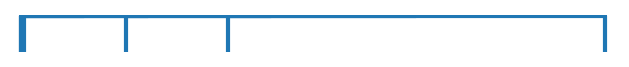

3.5


In [7]:
def _leaf_order_by_score_within_clusters_consistent_with_Z_new(
    Z,
    membership,
    scores,
    ascending=False,
):
    """
    Reorder leaves by score while remaining fully consistent with Z.

    Parameters
    ----------
    Z : ndarray, shape (n-1, 4) or (n-1, >=2)
        SciPy linkage matrix.
    membership : ndarray, shape (n,)
        Final cluster labels for each leaf.
    scores : ndarray, shape (n,)
        One score per original leaf/unit, e.g. PC1 weight.
    ascending : bool
        If True, lower-score subtree goes first.
        If False, higher-score subtree goes first.

    Returns
    -------
    leafOrder : ndarray, shape (n,)
        Leaf order consistent with Z.
    cluInLeafOrder : ndarray, shape (n,)
        Cluster labels aligned with leafOrder.
    """
    Z = np.asarray(Z)
    membership = np.asarray(membership, dtype=np.int32)
    scores = np.asarray(scores, dtype=np.float64)

    n = Z.shape[0] + 1
    total = 2 * n - 1

    # Relabel membership to 0..k-1 for stability
    _, membership = np.unique(membership, return_inverse=True)
    membership = membership.astype(np.int32, copy=False)

    children = np.empty((n - 1, 2), dtype=np.int32)
    heights = np.zeros(total, dtype=np.float64)
    heights[n:] = Z[:, 2]

    node_mean = np.zeros(total, dtype=np.float64)
    node_size = np.zeros(total, dtype=np.int32)

    # node_cluster >= 0 means the whole subtree belongs to one final cluster
    # node_cluster == -1 means mixed final clusters
    node_cluster = np.full(total, -1, dtype=np.int32)

    # Leaves
    node_mean[:n] = scores
    node_size[:n] = 1
    node_cluster[:n] = membership

    # Internal nodes
    for i in range(n - 1):
        a = int(Z[i, 0])
        b = int(Z[i, 1])

        # Optional sanity check
        if a >= n + i or b >= n + i:
            raise ValueError(
                f"Invalid linkage order at row {i}: children must be < {n+i}, got ({a}, {b})"
            )

        children[i, 0] = a
        children[i, 1] = b

        node = n + i
        sa, sb = node_size[a], node_size[b]
        node_size[node] = sa + sb
        node_mean[node] = (node_mean[a] * sa + node_mean[b] * sb) / (sa + sb)

        if node_cluster[a] == node_cluster[b]:
            node_cluster[node] = node_cluster[a]
        else:
            node_cluster[node] = -1

    def _original_child_order(a, b):
        ha, hb = heights[a], heights[b]
        if (ha < hb) or (ha == hb and a <= b):
            return a, b
        return b, a

    root = 2 * n - 2
    order = []

    # Iterative DFS to avoid RecursionError
    stack = [root]
    while stack:
        node = stack.pop()

        if node < n:
            order.append(node)
            continue

        i = node - n
        a = children[i, 0]
        b = children[i, 1]

        # Only allow score-based flip inside a pure final-cluster subtree
        if node_cluster[node] >= 0:
            if ascending:
                first, second = (a, b) if node_mean[a] <= node_mean[b] else (b, a)
            else:
                first, second = (a, b) if node_mean[a] >= node_mean[b] else (b, a)
        else:
            # Mixed subtree: preserve original tree order
            first, second = _original_child_order(a, b)

        # Push second first so that first is processed first
        stack.append(second)
        stack.append(first)

    leafOrder = np.asarray(order, dtype=np.int32)
    cluInLeafOrder = membership[leafOrder]
    return leafOrder, cluInLeafOrder


def _linkage_from_multilevel_levels_new(
    levels,
    best_idx,
    dataPCA=None,
    pc1_descending=True,
):
    """
    Build a SciPy-style linkage matrix from igraph multilevel levels,
    then compute a Z-consistent leaf order that is as aligned as possible
    with PC1 score inside each final cluster.

    Parameters
    ----------
    levels : list of igraph.clustering.VertexClustering
        Output of g.community_multilevel(weights="weight", return_levels=True)
    best_idx : int
        Index of the selected best level in the original levels list.
    dataPCA : ndarray, shape (n, T)
        Data used to compute PC1-based ordering.
    pc1_descending : bool
        If True, larger PC1 score goes first inside each final cluster.

    Returns
    -------
    Z : ndarray, shape (n-1, 4)
        SciPy linkage matrix.
    elbowIdx : int
        Compatibility index defined by kBest = n - (elbowIdx + 1).
    leafOrder : ndarray
        Leaf order consistent with Z and guided by PC1 score.
    cluInLeafOrder : ndarray
        Final cluster labels aligned with leafOrder.
    """
    if len(levels) == 0:
        raise ValueError("`levels` must be a non-empty list.")

    if dataPCA is None:
        raise ValueError("`dataPCA` must be provided.")

    memberships_raw = [np.asarray(cl.membership, dtype=np.int32) for cl in levels]
    n = memberships_raw[0].size

    # Sort levels from fine to coarse by number of clusters
    sizes_raw = np.array([len(cl) for cl in levels], dtype=np.int32)
    order = np.argsort(sizes_raw)[::-1]
    memberships_sorted = [memberships_raw[i] for i in order]
    sizes_sorted = sizes_raw[order]

    # Remove consecutive duplicate levels
    memberships = [memberships_sorted[0]]
    sizes_compact = [sizes_sorted[0]]
    map_sorted_to_compact = {0: 0}
    compact_idx = 0

    for i in range(1, len(memberships_sorted)):
        if np.array_equal(memberships_sorted[i], memberships[-1]):
            map_sorted_to_compact[i] = compact_idx
            continue
        memberships.append(memberships_sorted[i])
        sizes_compact.append(sizes_sorted[i])
        compact_idx += 1
        map_sorted_to_compact[i] = compact_idx

    sizes_sorted = np.array(sizes_compact, dtype=np.int32)

    # Map original best_idx to compact sorted level index
    best_sorted_idx = int(np.where(order == best_idx)[0][0])
    best_sorted_idx = map_sorted_to_compact[best_sorted_idx]

    # Final cluster labels must come from the selected best multilevel level
    membership_best = memberships[best_sorted_idx].copy()
    _, membership_best = np.unique(membership_best, return_inverse=True)
    membership_best = membership_best.astype(np.int32, copy=False)

    kBest = int(np.unique(membership_best).size)

    # Build a binary linkage-like hierarchy from level containments
    node_id = {}
    node_size = {}
    next_id = n
    merges = []

    # Level 0: build communities from leaves
    mem0 = memberships[0]
    for c in np.unique(mem0):
        leaves = np.flatnonzero(mem0 == c).astype(int).tolist()

        if len(leaves) == 1:
            node_id[(0, int(c))] = leaves[0]
            node_size[leaves[0]] = 1
        else:
            curr = leaves[0]
            curr_size = 1
            eps = 0.0
            for leaf in leaves[1:]:
                merges.append([curr, leaf, 1.0 + eps, curr_size + 1])
                curr = next_id
                node_size[curr] = curr_size + 1
                curr_size += 1
                next_id += 1
                eps += 1e-4
            node_id[(0, int(c))] = curr

    # Higher levels: merge previous communities into current communities
    for lev in range(1, len(memberships)):
        prev_mem = memberships[lev - 1]
        curr_mem = memberships[lev]

        for parent_c in np.unique(curr_mem):
            idx = np.flatnonzero(curr_mem == parent_c)
            child_labels = np.unique(prev_mem[idx]).astype(int).tolist()
            child_nodes = [node_id[(lev - 1, int(ch))] for ch in child_labels]

            if len(child_nodes) == 1:
                node_id[(lev, int(parent_c))] = child_nodes[0]
                continue

            curr = child_nodes[0]
            curr_size = node_size.get(curr, 1)
            eps = 0.0
            for ch in child_nodes[1:]:
                ch_size = node_size.get(ch, 1)
                merges.append([curr, ch, float(lev + 1) + eps, curr_size + ch_size])
                curr = next_id
                node_size[curr] = curr_size + ch_size
                curr_size += ch_size
                next_id += 1
                eps += 1e-4

            node_id[(lev, int(parent_c))] = curr

    Z = np.asarray(merges, dtype=np.float64)

    # If top level still has multiple roots, connect them
    if Z.shape[0] < n - 1:
        top_lev = len(memberships) - 1
        roots = [node_id[(top_lev, int(c))] for c in np.unique(memberships[top_lev])]

        if len(roots) > 1:
            extra = []
            curr = roots[0]
            curr_size = node_size.get(curr, 1)
            eps = 0.0
            for r in roots[1:]:
                r_size = node_size.get(r, 1)
                extra.append([curr, r, float(top_lev + 2) + eps, curr_size + r_size])
                curr = next_id
                node_size[curr] = curr_size + r_size
                curr_size += r_size
                next_id += 1
                eps += 1e-4
            if len(extra) > 0:
                Z = np.vstack([Z, np.asarray(extra, dtype=np.float64)])

    if Z.shape[0] != n - 1:
        raise ValueError(f"Constructed linkage has {Z.shape[0]} merges, expected {n - 1}.")


    def _leaf_order_distance_sort_new(Z, ascending=True):
        Z = np.asarray(Z)
        n = Z.shape[0] + 1
        root = 2 * n - 2
        heights = np.zeros(2 * n - 1, dtype=Z.dtype)
        heights[n:] = Z[:, 2]
        order = []
        stack = [root]
        while stack:
            node = stack.pop()
            if node < n:
                order.append(node)
                continue
            i = node - n
            left = int(Z[i, 0])
            right = int(Z[i, 1])
            hl = heights[left]
            hr = heights[right]
            if ascending:
                if (hl < hr) or (hl == hr and left <= right):
                    first, second = left, right
                else:
                    first, second = right, left
            else:
                if (hl > hr) or (hl == hr and left <= right):
                    first, second = left, right
                else:
                    first, second = right, left
            stack.append(second)
            stack.append(first)
        return np.asarray(order, dtype=np.int32)


    # Start from a tree-consistent order
    leafOrderTree = _leaf_order_distance_sort_new(Z)


    def _norm_m11(v):
        m = np.max(np.abs(v))
        return v / m if m > 0 else v


    # Compute PC1 score on the tree-consistent order
    if dataPCA is None:
        raise ValueError(
            "Please pass dataPCA, e.g. dataPCA = np.concatenate([frSmoothedZ, frSmoothedZAdd]) "
            "when calling this function."
        )
    dataPCA = np.asarray(dataPCA, float)
    dataPCA_ord = dataPCA[leafOrderTree, :]
    pca = PCA(n_components=2)  # PCA (features = units -> use X.T)
    pca.fit(dataPCA_ord.T)
    weights = pca.components_  # (2, n_units)
    pc1 = _norm_m11(weights[0])

    # Map PC1 score back to original leaf indexing
    pc1_score = np.empty(n, dtype=float)
    pc1_score[leafOrderTree] = pc1

    # Reorder inside each final cluster, but remain consistent with Z
    leafOrder, cluInLeafOrder = _leaf_order_by_score_within_clusters_consistent_with_Z_new(
        Z=Z,
        membership=membership_best,
        scores=pc1_score,
        ascending=(not pc1_descending),
    )
    print("unique clusters in cluInLeafOrder =", np.unique(cluInLeafOrder))

    # Keep compatibility with your existing interface
    elbowIdx = n - kBest - 1

    return Z, elbowIdx, leafOrder, cluInLeafOrder


def _compute_cut_height_from_kbest_new(Z, kBest, eps=1e-6):
    n = Z.shape[0] + 1
    h = Z[:, 2]
    i_cut = n - kBest - 1
    if i_cut < len(h) - 1:
        return 0.5 * (h[i_cut] + h[i_cut + 1])
    else:
        return h[i_cut] + eps


def plot_simplified_dendrogram_new(
    Z,
    leafOrder=None,
    K=10,
    y_floor=None,
    figsize=(12, 3),
    lw=2.0,
    color="C0",
    rasterized=True,
    capstyle="round",
    joinstyle="round",
    pad_frac_x=0.01,
    pad_frac_y=0.05,
    pad_min_x=5.0,
    pad_min_y=1e-6,
    savepath=None,
    show=True,
):
    Z = np.asarray(Z)
    m = Z.shape[0]
    n = m + 1
    total = 2 * n - 1

    # --- leaf order ---
    if leafOrder is None:
        leafOrder = np.arange(n, dtype=np.int32)
    else:
        leafOrder = np.asarray(leafOrder, dtype=np.int32)

    # --- positions (use NaN init to avoid garbage) ---
    x = np.full(total, np.nan, dtype=np.float64)
    y = np.zeros(total, dtype=np.float64)
    for pos, leaf in enumerate(leafOrder):
        x[int(leaf)] = float(pos)

    # --- store children + heights ---
    child = np.empty((m, 2), dtype=np.int32)
    h = Z[:, 2].astype(np.float64)

    # --- build internal nodes iteratively (requires valid linkage order) ---
    for i in range(m):
        a = int(Z[i, 0])
        b = int(Z[i, 1])
        child[i] = (a, b)
        node = n + i
        x[node] = (x[a] + x[b]) / 2.0
        y[node] = h[i]

    # --- choose last K merges ---
    start = max(0, m - int(K))
    segs = np.empty((3 * (m - start), 2, 2), dtype=np.float64)

    j = 0
    for i in range(start, m):
        a, b = child[i]
        height = h[i]
        xa, ya = x[a], y[a]
        xb, yb = x[b], y[b]
        if y_floor is not None:
            ya = max(ya, y_floor)
            yb = max(yb, y_floor)
        if xb < xa:
            xa, xb = xb, xa
            ya, yb = yb, ya
        segs[j + 0] = [(xa, ya), (xa, height)]
        segs[j + 1] = [(xa, height), (xb, height)]
        segs[j + 2] = [(xb, yb), (xb, height)]
        j += 3

        # --- plot ---
    fig, ax = plt.subplots(figsize=figsize, dpi=150)
    lc = LineCollection(segs, linewidths=lw, colors=color)
    lc.set_rasterized(rasterized)
    lc.set_capstyle(capstyle)
    lc.set_joinstyle(joinstyle)
    ax.add_collection(lc)

    # --- auto limits + padding (ONLY ONCE) ---
    xmin = np.nanmin(segs[:, :, 0])
    xmax = np.nanmax(segs[:, :, 0])
    ymin_seg = np.nanmin(segs[:, :, 1])
    ymax_seg = np.nanmax(segs[:, :, 1])

    pad_x = max(pad_min_x, pad_frac_x * (xmax - xmin))
    base_y = y_floor if y_floor is not None else ymin_seg
    pad_y = max(pad_min_y, pad_frac_y * max(1e-12, (ymax_seg - base_y)))

    ax.set_xlim(xmin - pad_x, xmax + pad_x)
    ax.set_ylim(base_y + pad_y, ymax_seg + pad_y)
    ax.set_axis_off()
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    if savepath is not None:
        fig.savefig(savepath, bbox_inches="tight", pad_inches=0)
    if show:
        plt.show()
    plt.close(fig)


Z, elbowIdx, leafOrder, cluInLeafOrder = _linkage_from_multilevel_levels_new(
    levels=levels,
    best_idx=best_idx,
    dataPCA=frSmoothedZ,
    pc1_descending=True,
)
cut_height = _compute_cut_height_from_kbest_new(Z, kBest)
plot_simplified_dendrogram_new(
    Z,
    leafOrder=leafOrder,
    K=25,
    y_floor=cut_height,
    figsize=(4, 0.25),
    lw=2.0,
    color="C0",
    savepath=None,
)
print(cut_height)

# -----------------------------
# 5) to final visualization
# -----------------------------

In [8]:
def graph_clustering_plot_refinement_pca_new(
    dataVisual,
    Z,
    kBest,
    leafOrder,
    cluInLeafOrder,
    dataPCA=None,
    plot=True,
):
    def _norm_m11(v):
        m = np.max(np.abs(v))
        return v / m if m > 0 else v

    def _stemh(ax, y, x):
        """Horizontal stem: baseline at 0, line to x, dot at x (y aligned with units)."""
        ax.axvline(0.0, linewidth=0.8)
        ax.hlines(y, 0.0, x, linewidth=0.6)
        ax.plot(x, y, marker="o", linestyle="None", markersize=1.5)

    if not plot:
        return

    n, T = dataVisual.shape

    # ---------- Base axes ----------
    fig, (axD, axH) = plt.subplots(
        1,
        2,
        figsize=(15, 12),
        gridspec_kw={"width_ratios": [0.5, 4.0]},
    )

    # ==================== Manual layout (add PCA panels on the right) ====================
    posD = axD.get_position()
    posH = axH.get_position()
    left = posD.x0
    right = posH.x1
    y0 = posD.y0
    height = posD.height

    wD_rel = 0.8
    wH_rel = 4.0
    wPCA_rel = 1.6

    gap_DH = 0.02
    gap_pca = 0.05
    gap_pc = 0.025

    total_rel = wD_rel + wH_rel + 2 * wPCA_rel
    total_gap = gap_DH + gap_pca + gap_pc
    total_width = right - left
    unit = (total_width - total_gap) / total_rel

    wD = wD_rel * unit
    wH = wH_rel * unit
    wPC1 = wPCA_rel * unit
    wPC2 = wPCA_rel * unit

    xD = left
    xH = xD + wD + gap_DH
    xPC1 = xH + wH + gap_pca
    xPC2 = xPC1 + wPC1 + gap_pc

    axD.set_position([xD, y0, wD, height])
    axH.set_position([xH, y0, wH, height])

    axPC1 = fig.add_axes([xPC1, y0, wPC1, height])
    axPC2 = fig.add_axes([xPC2, y0, wPC2, height])
    # ============================================================================

    # ---------------------- dendrogram ----------------------
    cut_h = compute_cut_height_from_kbest_new(Z, kBest)
    plot_simplified_dendrogram_on_ax_new(
        ax=axD,
        Z=Z,
        leafOrder=leafOrder,
        y_floor=cut_h,
        lw=2,
        color="k",
        rasterized=True,
        pad_frac_x=0.01,
    )
    axD.set_title("Clusters" + "\n" + f"(k={kBest})", fontweight="bold")

    # ---------------------- heatmap ----------------------
    im = axH.imshow(
        dataVisual[leafOrder, :],
        cmap="bwr",
        origin="lower",
        aspect="auto",
        vmin=-1,
        vmax=1,
    )

    # x ticks
    n_xticks = 5
    xticks = np.linspace(0, T - 1, n_xticks)
    # xticklabels = np.round(xticks * dtFR, 2)
    axH.set_xticks(xticks)
    # axH.set_xticklabels(xticklabels)

    axH.set_yticks([0, int((n - 1) / 2), (n - 1)])
    axH.set_yticklabels([1, int((n - 1) / 2) + 1, n])
    axH.tick_params(direction="in")
    axH.yaxis.set_label_position("right")
    axH.yaxis.tick_right()
    axH.set_ylabel("GOOD units (clustered)", fontweight="bold")
    axH.set_xlabel("Time (s)")

    # cluster separation
    boundaries = np.where(np.diff(cluInLeafOrder) != 0)[0] + 0.5
    for b in boundaries:
        axH.axhline(b, color="k", linewidth=1)

    # ---------------------- PCA weights on the right ----------------------
    if dataPCA is None:
        raise ValueError(
            "Please pass dataPCA, e.g. dataPCA = np.concatenate([frSmoothedZ, frSmoothedZAdd]) "
            "when calling this function."
        )

    dataPCA = np.asarray(dataPCA, float)
    dataPCA_ord = dataPCA[leafOrder, :]

    pca = PCA(n_components=2)  # PCA (features = units -> use X.T)
    pca.fit(dataPCA_ord.T)
    weights = pca.components_  # (2, n_units)
    pc1 = _norm_m11(weights[0])
    pc2 = _norm_m11(weights[1])

    y = np.arange(n)
    for ax in (axPC1, axPC2):
        ax.set_ylim(-0.5, n - 0.5)
        ax.set_xlim(-1.0, 1.0)
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([])
        ax.tick_params(direction="in")
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(True)

    axPC1.set_title("PC1" + "\n" + "Weights", fontweight="bold")
    axPC2.set_title("PC2" + "\n" + "Weights", fontweight="bold")

    _stemh(axPC1, y, pc1)
    _stemh(axPC2, y, pc2)

    # ---------------------- colorbar ----------------------
    bbox_h = axH.get_position()
    cbar_height = 0.015
    cbar_pad = 0.025
    cbar_x0 = bbox_h.x0
    cbar_width = bbox_h.width
    cbar_y0 = bbox_h.y0 - cbar_pad - cbar_height
    cax = fig.add_axes([cbar_x0, cbar_y0, cbar_width, cbar_height])
    cbar = fig.colorbar(im, cax=cax, orientation="horizontal")
    cbar.set_label("Z-scored FR (Hz)", fontweight="bold")
    cbar.ax.xaxis.labelpad = 0
    cbar.set_ticks([-1, 1])
    cbar.ax.tick_params(direction="in")

    plt.show()

def compute_cut_height_from_kbest_new(Z, kBest, eps=1e-6):
    n = Z.shape[0] + 1
    h = Z[:, 2]
    i_cut = n - kBest - 1
    if i_cut < len(h) - 1:
        return 0.5 * (h[i_cut] + h[i_cut + 1])
    else:
        return h[i_cut] + eps


def plot_simplified_dendrogram_on_ax_new(
    ax,
    Z,
    leafOrder=None,
    y_floor=None,
    lw=0.5,
    color="k",
    rasterized=True,
    capstyle="round",
    joinstyle="round",
    pad_frac_x=0.05,
    pad_frac_y=0.01,
    pad_min_x=1e-6,
    pad_min_y=0.5,
    show_cluster_ids=False,
    cluster_id_prefix="C",
    cluster_id_fs=8,
    cluster_id_color="gray",
    cluster_id_xpad_frac=0.02,
):
    Z = np.asarray(Z)
    m = Z.shape[0]
    n = m + 1
    total = 2 * n - 1

    # --- leaf order ---
    if leafOrder is None:
        leafOrder = np.arange(n, dtype=np.int32)
    else:
        leafOrder = np.asarray(leafOrder, dtype=np.int32)

    # --- node positions ---
    x = np.full(total, np.nan, dtype=np.float64)  # dendrogram distance axis
    y = np.full(total, np.nan, dtype=np.float64)  # leaf-position axis

    # leaves placed according to given order
    for pos, leaf in enumerate(leafOrder):
        y[int(leaf)] = float(pos)

    # internal nodes
    child = np.empty((m, 2), dtype=np.int32)
    h = Z[:, 2].astype(np.float64)

    for i in range(m):
        a = int(Z[i, 0])
        b = int(Z[i, 1])
        child[i] = (a, b)
        node = n + i
        x[node] = h[i]
        y[node] = (y[a] + y[b]) / 2.0

    # leaves live at x=0
    x[:n] = 0.0

    # --- build only segments above the cut ---
    segs = []
    cluster_label_pos = []
    for i in range(m):
        height = h[i]
        if y_floor is not None and height < y_floor:
            continue
        a, b = child[i]
        xa, ya = x[a], y[a]
        xb, yb = x[b], y[b]
        if y_floor is not None:
            xa = max(xa, y_floor)
            xb = max(xb, y_floor)
        if ya > yb:
            xa, xb = xb, xa
            ya, yb = yb, ya
            a, b = b, a
        segs.append([(xa, ya), (height, ya)])
        segs.append([(height, ya), (height, yb)])
        segs.append([(xb, yb), (height, yb)])
        if y_floor is None:
            if i == m - 1:
                cluster_label_pos.append(0.5 * (ya + yb))
        else:
            if a < n or x[a] < y_floor:
                cluster_label_pos.append(ya)
            if b < n or x[b] < y_floor:
                cluster_label_pos.append(yb)

    ax.cla()
    if len(segs) == 0:
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_visible(False)
        return

    segs = np.asarray(segs, dtype=np.float64)
    lc = LineCollection(segs, linewidths=lw, colors=color)
    lc.set_rasterized(rasterized)
    lc.set_capstyle(capstyle)
    lc.set_joinstyle(joinstyle)
    ax.add_collection(lc)
    xmin = np.nanmin(segs[:, :, 0])
    xmax = np.nanmax(segs[:, :, 0])
    pad_x = max(pad_min_x, pad_frac_x * max(1e-12, xmax - xmin))
    ax.set_xlim(xmax + pad_x, xmin - pad_x)
    ax.set_ylim(-0.5, n - 0.5)

    if show_cluster_ids:
        dx = cluster_id_xpad_frac * max(1e-12, xmax - xmin)

        if y_floor is None:
            x_text = xmin - dx
        else:
            x_text = y_floor - 60 * dx
        cluster_label_pos = sorted(cluster_label_pos)
        for ic, y_lab in enumerate(cluster_label_pos, start=1):
            if ic in [3, 5]:
                ax.text(
                    x_text,
                    y_lab,
                    f"{cluster_id_prefix}{ic}",
                    ha="right",
                    va="center",
                    fontsize=cluster_id_fs,
                    fontweight="bold",
                    color="k",
                    clip_on=False,
                )
            else:
                ax.text(
                    x_text,
                    y_lab,
                    f"{cluster_id_prefix}{ic}",
                    ha="right",
                    va="center",
                    fontsize=cluster_id_fs,
                    color=cluster_id_color,
                    clip_on=False,
                )

    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    for spine in ax.spines.values():
        spine.set_visible(False)

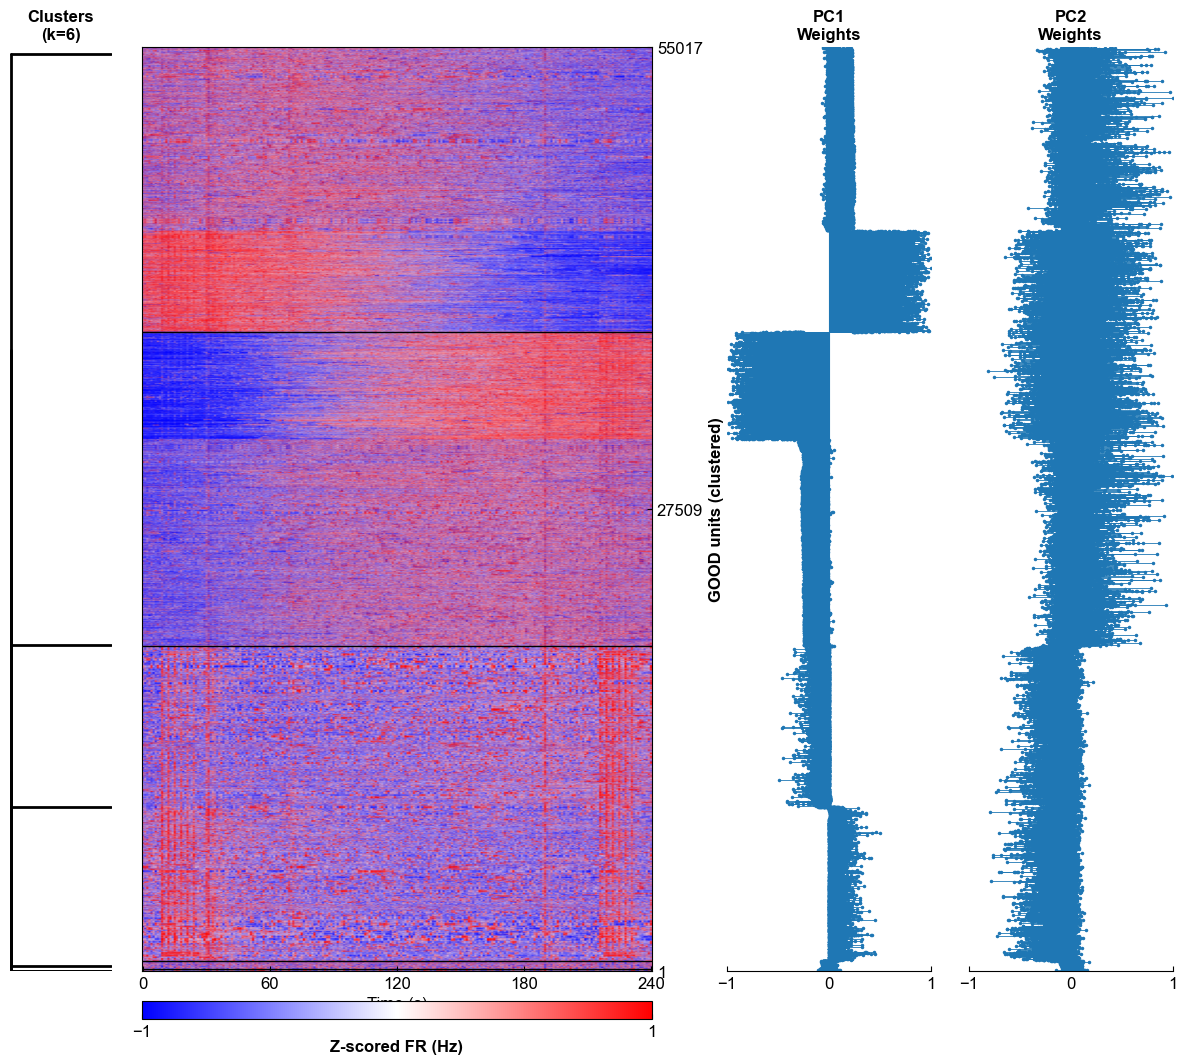

In [9]:
graph_clustering_plot_refinement_pca_new(
    dataVisual=frSmoothedVisualZ,
    Z=Z,
    kBest=kBest,
    leafOrder=leafOrder,
    cluInLeafOrder=cluInLeafOrder,
    dataPCA=frSmoothedZ,
)